In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import json
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

TRAIN_DIR = r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\LWDCD\dataset_split\train"
VAL_DIR = r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\LWDCD\dataset_split\val"
TEST_DIR = r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\LWDCD\dataset_split\test"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = train_generator.num_classes

Found 2351 images belonging to 3 classes.
Found 506 images belonging to 3 classes.
Found 505 images belonging to 3 classes.


In [4]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [5]:
inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "VGG16_transfer_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,848,835 (56.64 MB)

 Trainable params: 133,123 (520.01 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [6]:
history_head = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks
)

base_model.trainable = True

C:\Users\KristianHaltenJensen\anaconda4\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4044 - loss: 1.3586
Epoch 1: val_accuracy improved from -inf to 0.63834, saving model to VGG16_transfer_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.4054 - loss: 1.3563 - val_accuracy: 0.6383 - val_loss: 0.8636 - learning_rate: 1.0000e-04
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6340 - loss: 0.8250
Epoch 2: val_accuracy improved from 0.63834 to 0.75692, saving model to VGG16_transfer_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.6341 - loss: 0.8253 - val_accuracy: 0.7569 - val_loss: 0.6464 - learning_rate: 1.0000e-04
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6873 - loss: 0.7639
Epoch 3: val_accuracy improved from 0.75692 to 0.79447, saving model to VGG16_transfer_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 261s 4s/step - accuracy: 0.6875 - loss: 0.7635 - val_accuracy: 0.7945 - val_loss: 0.5768 - learning_rate: 1.0000e-04
Epoch 4/50
74/74 ━━━━━━━━━━━

In [7]:
base_model.trainable = True

for layer in base_model.layers[:15]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8968 - loss: 0.2884
Epoch 1: val_accuracy improved from 0.90711 to 0.91502, saving model to VGG16_transfer_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 194s 3s/step - accuracy: 0.8969 - loss: 0.2882 - val_accuracy: 0.9150 - val_loss: 0.2044 - learning_rate: 1.0000e-05
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9055 - loss: 0.2500
Epoch 2: val_accuracy improved from 0.91502 to 0.94862, saving model to VGG16_transfer_best.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 192s 3s/step - accuracy: 0.9057 - loss: 0.2498 - val_accuracy: 0.9486 - val_loss: 0.1659 - learning_rate: 1.0000e-05
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9216 - loss: 0.2078
Epoch 3: val_accuracy did not improve from 0.94862
74/74 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.9216 - loss: 0.2078 - val_accuracy: 0.9427 - val_loss: 0.1508 - learning_rate: 1.0000e-05
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9317 - lo

In [8]:


pred_probs = model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step
                  precision    recall  f1-score   support

   Healthy Wheat       0.95      0.95      0.95       175
       Leaf Rust       0.97      0.95      0.96       190
Wheat Loose Smut       0.94      0.96      0.95       140

        accuracy                           0.95       505
       macro avg       0.95      0.95      0.95       505
    weighted avg       0.95      0.95      0.95       505

[[167   4   4]
 [  5 181   4]
 [  4   2 134]]


In [9]:

with open("VGG16_head_history_LWDCD.json", "w") as f:
    json.dump(history_head.history, f)

In [10]:
with open("VGG16_finetune_history_LWDCD.json", "w") as f:
    json.dump(history_fine.history, f)

In [11]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9524 - loss: 0.1462
Test accuracy: 0.9545


In [12]:


pred_probs = model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step
                  precision    recall  f1-score   support

   Healthy Wheat       0.95      0.95      0.95       175
       Leaf Rust       0.97      0.95      0.96       190
Wheat Loose Smut       0.94      0.96      0.95       140

        accuracy                           0.95       505
       macro avg       0.95      0.95      0.95       505
    weighted avg       0.95      0.95      0.95       505

[[167   4   4]
 [  5 181   4]
 [  4   2 134]]


In [13]:
model.save("VGG16_finetuned_LWDCD.keras")

In [14]:
model.save("VGG16_head_LWDCD.keras")

Loaded model.
Top-level layers:
0 input_layer_2 InputLayer
1 vgg16 Functional
2 global_average_pooling2d GlobalAveragePooling2D
3 batch_normalization BatchNormalization
4 dense Dense
5 dropout Dropout
6 dense_1 Dense
Backbone: vgg16

Backbone layers:
0 block3_conv3 Conv2D
1 block3_pool MaxPooling2D
2 block4_conv1 Conv2D
3 block4_conv2 Conv2D
4 block4_conv3 Conv2D
5 block4_pool MaxPooling2D
6 block5_conv1 Conv2D
7 block5_conv2 Conv2D
8 block5_conv3 Conv2D
9 block5_pool MaxPooling2D

Image: C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\leaf rust.jpg
Predicted class: Leaf Rust
Confidence: 1.0000 (100.00%)

Top predictions:
  Leaf Rust                 1.0000 (100.00%)
  Healthy Wheat             0.0000 (0.00%)
  Wheat Loose Smut          0.0000 (0.00%)


C:\Users\KristianHaltenJensen\anaconda4\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)



Image: C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\Healthy leaf.jpg
Predicted class: Leaf Rust
Confidence: 0.9967 (99.67%)

Top predictions:
  Leaf Rust                 0.9967 (99.67%)
  Healthy Wheat             0.0031 (0.31%)
  Wheat Loose Smut          0.0001 (0.01%)

Image: C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\wheat loose smut.jpg
Predicted class: Wheat Loose Smut
Confidence: 1.0000 (100.00%)

Top predictions:
  Wheat Loose Smut          1.0000 (100.00%)
  Healthy Wheat             0.0000 (0.00%)
  Leaf Rust                 0.0000 (0.00%)


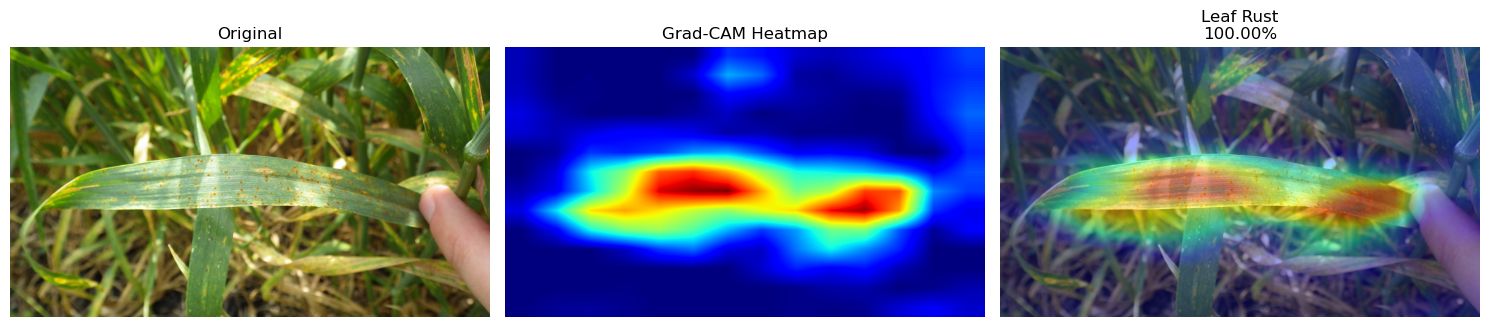

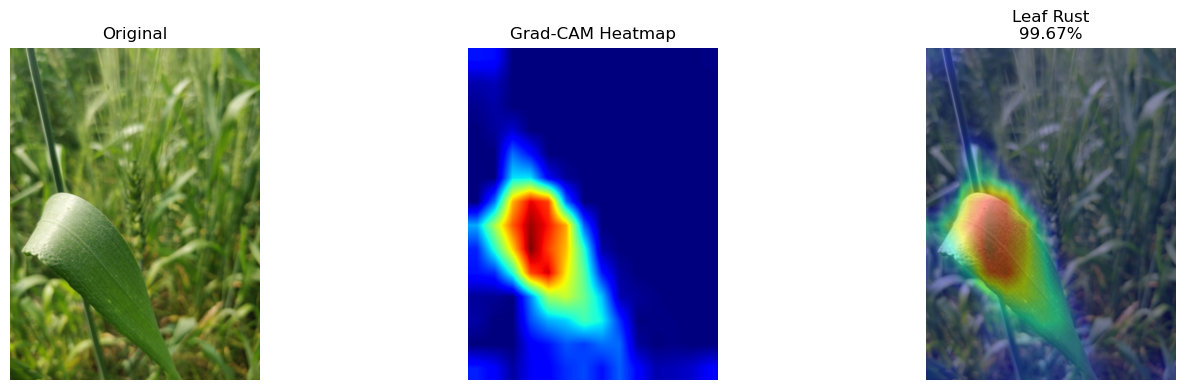

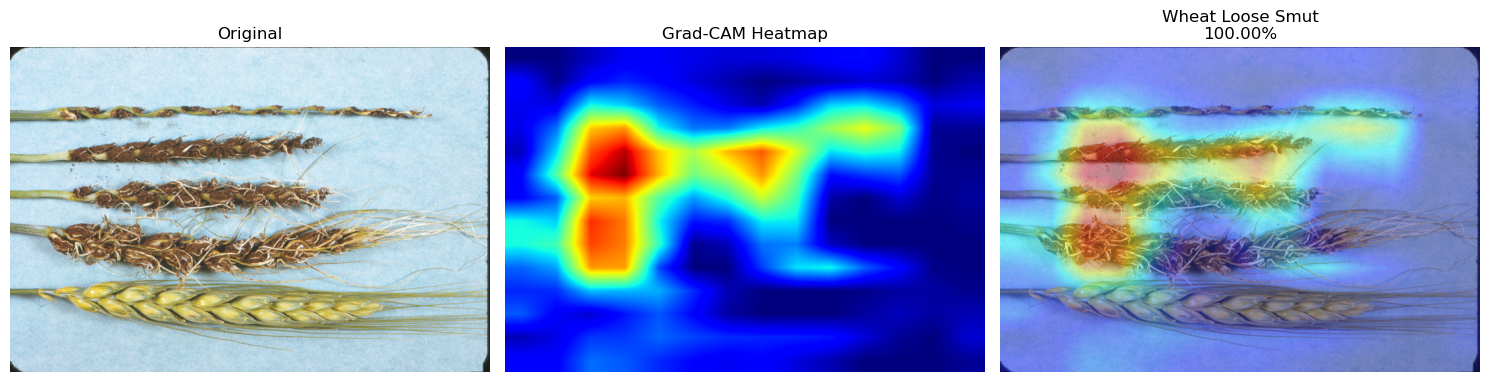

In [5]:
import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image

# =========================
# PATHS
# =========================
MODEL_PATH = "VGG16_finetuned_LWDCD.keras"
CLASS_JSON = "class_names_LWDC.json"

IMAGE_PATHS = [
    r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\leaf rust.jpg",
    r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\Healthy leaf.jpg",
    r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\wheat loose smut.jpg",
]

IMG_SIZE = (224, 224)

# =========================
# LOAD MODEL
# =========================
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

with open(CLASS_JSON, "r", encoding="utf-8") as f:
    class_names = json.load(f)

print("Loaded model.")
print("Top-level layers:")
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

base_model = model.get_layer("vgg16")
print("Backbone:", base_model.name)

# Optional: inspect backbone layers
print("\nBackbone layers:")
for i, layer in enumerate(base_model.layers[-10:]):
    print(i, layer.name, layer.__class__.__name__)

# =========================
# PREPROCESS
# =========================
def load_and_preprocess_image(img_path, target_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

# =========================
# FIND LAST CONV LAYER IN VGG16 BACKBONE
# =========================
last_conv_layer_name = "block5_conv3"

conv_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=base_model.get_layer(last_conv_layer_name).output
)

# Layers after last conv inside VGG16
block5_pool = base_model.get_layer("block5_pool")

# Top classifier head from your full model
gap_layer = model.get_layer("global_average_pooling2d")
bn_layer = model.get_layer("batch_normalization")
dense_layer = model.get_layer("dense")
dropout_layer = model.get_layer("dropout")
classifier_layer = model.get_layer("dense_1")

# =========================
# GRAD-CAM
# =========================
def make_gradcam_heatmap(
    img_array,
    conv_model,
    pool_layer,
    gap_layer,
    bn_layer,
    dense_layer,
    dropout_layer,
    classifier_layer,
    pred_index=None
):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model([img_tensor], training=False)
        tape.watch(conv_outputs)

        x = pool_layer(conv_outputs)
        x = gap_layer(x)
        x = bn_layer(x, training=False)
        x = dense_layer(x)
        x = dropout_layer(x, training=False)
        preds = classifier_layer(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_score = preds[:, pred_index]

    grads = tape.gradient(class_score, conv_outputs)

    conv_outputs = conv_outputs[0]
    grads = grads[0]

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

# =========================
# OVERLAY
# =========================
def overlay_heatmap(img_path, heatmap, alpha=0.4):
    original_bgr = cv2.imread(img_path)
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

    heatmap_resized = cv2.resize(heatmap, (original_rgb.shape[1], original_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(original_rgb, 1 - alpha, heatmap_color, alpha, 0)
    return original_rgb, heatmap_resized, overlay

# =========================
# RUN ON IMAGES
# =========================
results = []

for img_path in IMAGE_PATHS:
    print("\n" + "=" * 70)
    print("Image:", img_path)

    img_array = load_and_preprocess_image(img_path)
    preds = model.predict(img_array, verbose=0)[0]

    pred_idx = int(np.argmax(preds))
    pred_class = class_names[pred_idx]
    confidence = float(preds[pred_idx])

    sorted_probs = sorted(zip(class_names, preds), key=lambda x: x[1], reverse=True)

    print("Predicted class:", pred_class)
    print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    print("\nTop predictions:")
    for cls, prob in sorted_probs:
        print(f"  {cls:25s} {prob:.4f} ({prob*100:.2f}%)")

    heatmap = make_gradcam_heatmap(
        img_array=img_array,
        conv_model=conv_model,
        pool_layer=block5_pool,
        gap_layer=gap_layer,
        bn_layer=bn_layer,
        dense_layer=dense_layer,
        dropout_layer=dropout_layer,
        classifier_layer=classifier_layer,
        pred_index=pred_idx
    )

    original_rgb, heatmap_resized, overlay = overlay_heatmap(img_path, heatmap)

    results.append({
        "img_path": img_path,
        "pred_class": pred_class,
        "confidence": confidence,
        "probs": sorted_probs,
        "original": original_rgb,
        "heatmap": heatmap_resized,
        "overlay": overlay
    })

# =========================
# DISPLAY
# =========================
for r in results:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(r["original"])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(r["heatmap"], cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(r["overlay"])
    plt.title(f'{r["pred_class"]}\n{r["confidence"]*100:.2f}%')
    plt.axis("off")

    plt.tight_layout()
    plt.show()

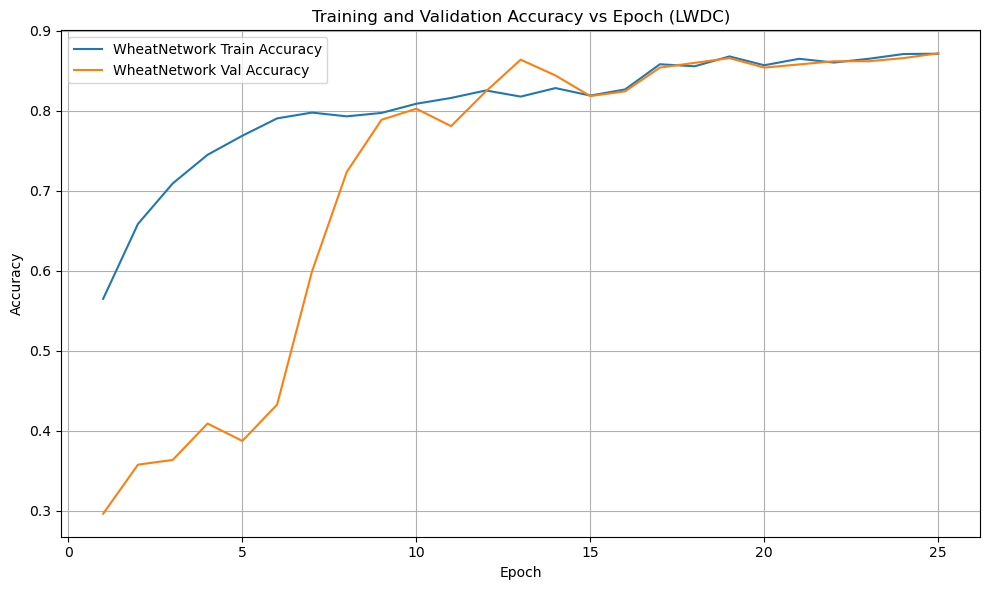

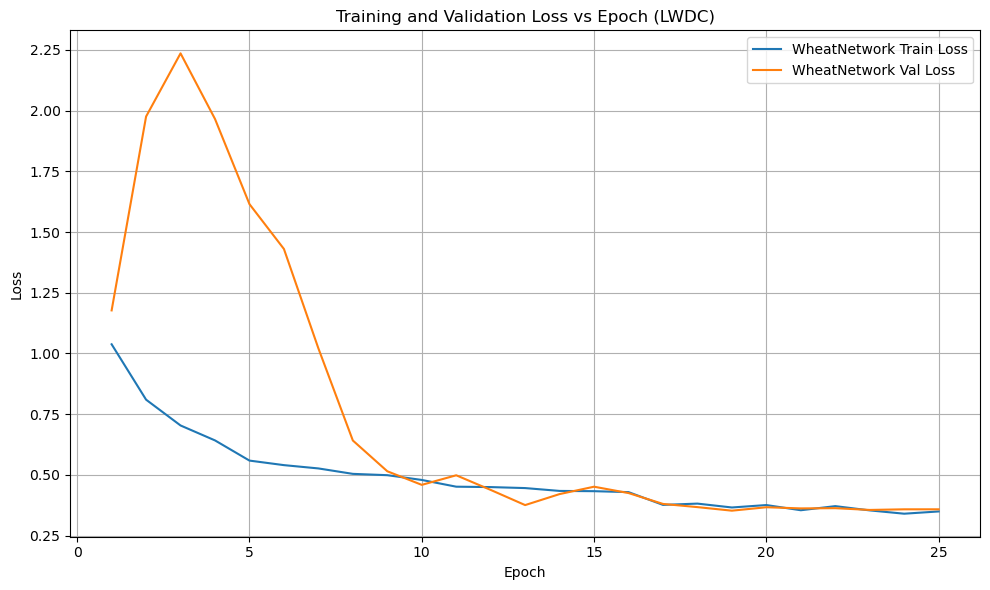

In [14]:
import json
import matplotlib.pyplot as plt

# ==========================================
# FILE PATHS
# ==========================================
json_files = {
    #"ResNet50": "resnet50_head_history_LWDCD.json",
    #"VGG16": "vgg16_head_history_LWDCD.json",
    # "MobileNetV2": "mobilenetv2_head_history.json",
    # "InceptionV3": "inceptionv3_head_history.json",
     "WheatNetwork": "wheatnetwork_history_LWDCD.json",
}

# ==========================================
# LOAD HISTORIES
# ==========================================
histories = {}

for model_name, file_path in json_files.items():
    with open(file_path, "r") as f:
        histories[model_name] = json.load(f)

# ==========================================
# ACCURACY PLOT
# ==========================================
plt.figure(figsize=(10, 6))

for model_name, history in histories.items():
    epochs = range(1, len(history["accuracy"]) + 1)

    plt.plot(epochs, history["accuracy"],  label=f"{model_name} Train Accuracy")
    plt.plot(epochs, history["val_accuracy"], label=f"{model_name} Val Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy vs Epoch (LWDC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# LOSS PLOT
# ==========================================
plt.figure(figsize=(10, 6))

for model_name, history in histories.items():
    epochs = range(1, len(history["loss"]) + 1)

    plt.plot(epochs, history["loss"], label=f"{model_name} Train Loss")
    plt.plot(epochs, history["val_loss"], label=f"{model_name} Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epoch (LWDC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
import sys
print(sys.version)

3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]
